# WikiNews NLP Project — Semantic Similarity Analysis

This notebook evaluates how well the generated summaries preserve the semantic meaning of the original WikiNews articles.

The main goals are to:

- generate semantic embeddings for original articles and summaries,
- calculate cosine similarity scores,
- analyse similarity distributions,
- compare similarity across news categories,
- identify the highest- and lowest-similarity summaries,
- investigate the relationship between compression and semantic similarity.

## 1. Imports and Data Loading

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_ROOT = Path("..").resolve()

In [18]:
SUMMARY_PATH = PROJECT_ROOT / "data/processed/summaries.csv"

summaries_df = pd.read_csv(SUMMARY_PATH)

print("Dataset shape:", summaries_df.shape)
print("\nCategory distribution:")
print(summaries_df["primary_category"].value_counts())

Dataset shape: (60, 12)

Category distribution:
primary_category
Politics and conflicts    15
Economy and business      15
Science and technology    15
Sports                    15
Name: count, dtype: int64


## 2. Sentence Embedding Model

SentenceTransformer embeddings are used to represent original articles and summaries as dense semantic vectors.

In [19]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded.


In [20]:
original_embeddings = model.encode(
    summaries_df["text"].tolist(),
    show_progress_bar=True,
)

summary_embeddings = model.encode(
    summaries_df["summary"].tolist(),
    show_progress_bar=True,
)

print("Original embeddings shape:", original_embeddings.shape)
print("Summary embeddings shape:", summary_embeddings.shape)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Original embeddings shape: (60, 384)
Summary embeddings shape: (60, 384)


## 3. Semantic Similarity Scores

Cosine similarity is used to measure how closely each summary matches the semantic meaning of its original article.

Scores closer to 1 indicate stronger semantic similarity.

In [21]:
similarity_scores = []

for original_embedding, summary_embedding in zip(
    original_embeddings,
    summary_embeddings,
):
    score = cosine_similarity(
        [original_embedding],
        [summary_embedding],
    )[0][0]

    similarity_scores.append(score)

summaries_df["similarity_score"] = similarity_scores

summaries_df[
    [
        "title",
        "primary_category",
        "similarity_score",
    ]
].head()

,title,primary_category,similarity_score
0,Brazilian President party received money from ...,Politics and conflicts,0.991213
1,Burundian Hutu extremists have killed 300 civi...,Politics and conflicts,0.891985
2,Spanish Socialist Workers' Party proposes huma...,Politics and conflicts,0.869703
3,Kurds announce deal with Assad's government as...,Politics and conflicts,0.856832
4,IRA disbands military structure,Politics and conflicts,0.784382


In [22]:
summaries_df["similarity_score"].describe()

count    60.000000
mean      0.841295
std       0.078727
min       0.612907
25%       0.799572
50%       0.860272
75%       0.884928
max       0.991213
Name: similarity_score, dtype: float64

In [23]:
print(
    "Mean similarity:",
    round(
        summaries_df["similarity_score"].mean(),
        3,
    ),
)

print(
    "Median similarity:",
    round(
        summaries_df["similarity_score"].median(),
        3,
    ),
)

print(
    "Articles with similarity > 0.8:",
    (
        summaries_df["similarity_score"] > 0.8
    ).sum(),
)

Mean similarity: 0.841
Median similarity: 0.86
Articles with similarity > 0.8: 45


## 4. Similarity Score Distribution

The distribution of cosine similarity scores is visualized to understand how consistently the summaries preserve semantic meaning.

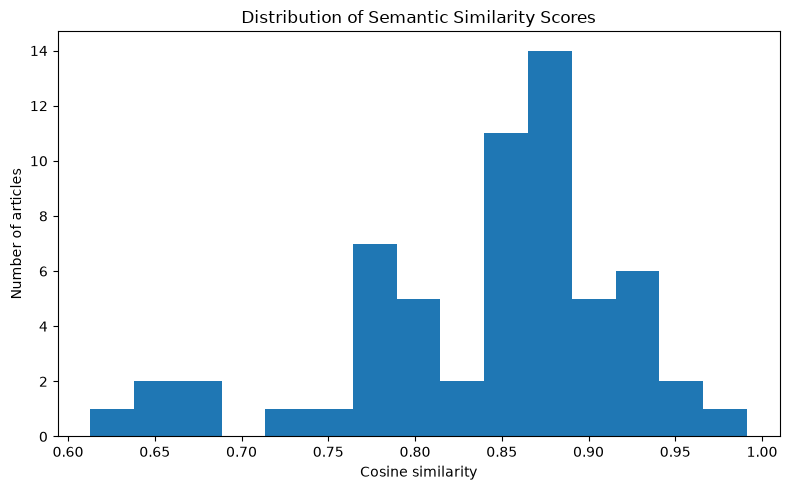

In [24]:
summaries_df["similarity_score"].plot(
    kind="hist",
    bins=15,
    figsize=(8, 5),
    title="Distribution of Semantic Similarity Scores",
)

plt.xlabel("Cosine similarity")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

## 5. Similarity by News Category

Similarity scores are compared across the four selected news categories to identify whether summarization performance varies by topic.

In [25]:
category_similarity = (
    summaries_df.groupby(
        "primary_category"
    )["similarity_score"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .round(3)
)

category_similarity

,count,mean,median,min,max
primary_category,,,,,
Economy and business,15,0.874,0.865,0.802,0.962
Politics and conflicts,15,0.860,0.866,0.662,0.991
Science and technology,15,0.821,0.847,0.613,0.917
Sports,15,0.810,0.849,0.642,0.922


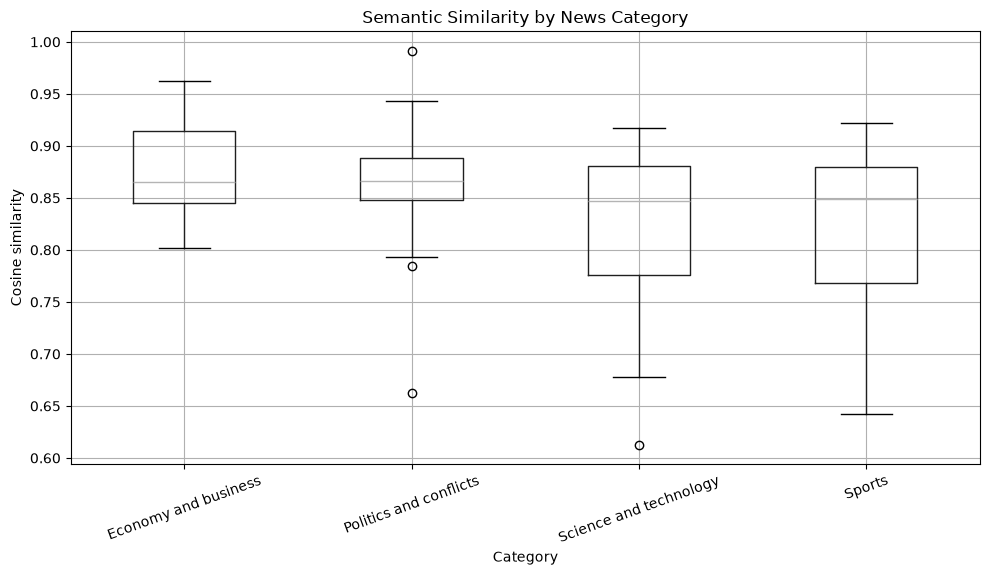

In [26]:
summaries_df.boxplot(
    column="similarity_score",
    by="primary_category",
    figsize=(10, 6),
    rot=20,
)

plt.title("Semantic Similarity by News Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Cosine similarity")
plt.tight_layout()
plt.show()

## 6. Highest-Similarity Summaries

The highest-scoring summaries are inspected to identify cases where the main semantic content was preserved most effectively.

In [27]:
highest_similarity = summaries_df.nlargest(
    5,
    "similarity_score",
)

highest_similarity[
    [
        "title",
        "primary_category",
        "original_word_count",
        "summary_word_count",
        "compression_ratio",
        "similarity_score",
    ]
]

,title,primary_category,original_word_count,summary_word_count,compression_ratio,similarity_score
0,Brazilian President party received money from ...,Politics and conflicts,2380,950,0.399160,0.991213
22,Romania redenominates its currency,Economy and business,607,217,0.357496,0.962428
13,"Karl Rove, senior political advisor to Preside...",Politics and conflicts,116,45,0.387931,0.943523
23,Market maker Bernard L. Madoff arrested in $50...,Economy and business,701,224,0.319544,0.932771
29,Free Software Foundation releases first draft ...,Economy and business,337,123,0.364985,0.927995


## 7. Lowest-Similarity Summaries

The lowest-scoring summaries are inspected to identify cases where article complexity, multiple subtopics, or stronger compression may have reduced semantic coverage.

In [28]:
lowest_similarity = summaries_df.nsmallest(
    5,
    "similarity_score",
)

lowest_similarity[
    [
        "title",
        "primary_category",
        "original_word_count",
        "summary_word_count",
        "compression_ratio",
        "similarity_score",
    ]
]

,title,primary_category,original_word_count,summary_word_count,compression_ratio,similarity_score
34,SpaceX launches first Falcon 9 rocket,Science and technology,348,101,0.290230,0.612907
57,Lewis Hamilton wins 2008 Monaco Grand Prix,Sports,355,98,0.276056,0.642033
8,Bomb explosion in Somaliland kills four cops,Politics and conflicts,185,44,0.237838,0.662346
46,Tour de France: Filippo Pozzato wins stage 5,Sports,104,30,0.288462,0.668753
31,India's first lunar mission launched,Science and technology,271,78,0.287823,0.678021


In [29]:
for _, row in lowest_similarity.iterrows():
    print("=" * 90)
    print("TITLE:", row["title"])
    print("CATEGORY:", row["primary_category"])
    print(
        "SIMILARITY:",
        round(row["similarity_score"], 3),
    )
    print(
        "COMPRESSION:",
        round(row["compression_ratio"], 3),
    )

    print("\nSUMMARY:")
    print(row["summary"])
    print()

TITLE: SpaceX launches first Falcon 9 rocket
CATEGORY: Science and technology
SIMILARITY: 0.613
COMPRESSION: 0.29

SUMMARY:
The program is intended to help develop commercial space transportation, a goal that fits with President Obama's recent change of direction for NASA. However, no private firms yet have the capability to independently launch humans into space, without NASA assistance. "Today the commercial providers that NASA has contracted with cannot even carry the trash back from the space station, much less carry humans to or from space safely," the Senator said. Although today's launch succeeded, Musk had said earlier neither the success nor failure of the Falcon 9 would be the ultimate arbitrator of the fate of NASA's new commercial-friendly direction.

TITLE: Lewis Hamilton wins 2008 Monaco Grand Prix
CATEGORY: Sports
SIMILARITY: 0.642
COMPRESSION: 0.276

SUMMARY:
Last year, he finished in second place after his former teammate Fernando Alonso. In this race Alonso finished o

## 8. Compression Ratio vs Semantic Similarity

The relationship between compression ratio and semantic similarity is analysed to investigate the trade-off between shorter summaries and information retention.

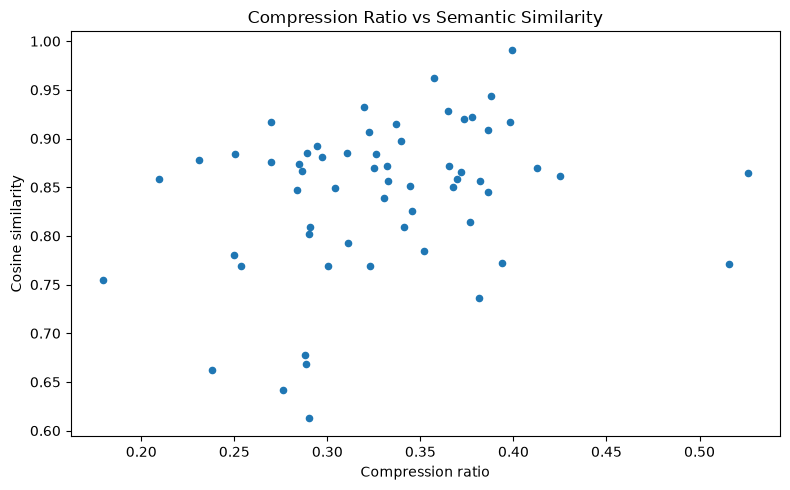

In [30]:
summaries_df.plot.scatter(
    x="compression_ratio",
    y="similarity_score",
    figsize=(8, 5),
    title="Compression Ratio vs Semantic Similarity",
)

plt.xlabel("Compression ratio")
plt.ylabel("Cosine similarity")
plt.tight_layout()
plt.show()

In [31]:
correlation = summaries_df[
    [
        "compression_ratio",
        "similarity_score",
    ]
].corr().iloc[0, 1]

print(
    "Correlation between compression ratio and similarity:",
    round(correlation, 3),
)

Correlation between compression ratio and similarity: 0.275


## 9. Save Similarity Results

In [32]:
SIMILARITY_PATH = (
    PROJECT_ROOT
    / "data/processed/similarity_scores.csv"
)

columns_to_save = [
    "pageid",
    "title",
    "primary_category",
    "original_word_count",
    "summary_word_count",
    "compression_ratio",
    "similarity_score",
]

summaries_df[
    columns_to_save
].to_csv(
    SIMILARITY_PATH,
    index=False,
)

print("Saved:", SIMILARITY_PATH)

Saved: /workspaces/rigoel-NLP.AI.2.5/data/processed/similarity_scores.csv


## Key Findings

- The mean semantic similarity between original articles and summaries is approximately 0.84.
- The median similarity is approximately 0.86.
- 45 of the 60 summaries achieve a similarity score above 0.8.
- These results suggest that the extractive summarization approach generally preserves the main semantic content of the source articles.
- Similarity varies across articles and categories, so the highest- and lowest-scoring cases are inspected separately.
- Lower-scoring summaries may reflect articles containing multiple subtopics, complex narrative structure, or stronger information loss during compression.
- Compression ratio is analysed together with similarity to assess the trade-off between conciseness and semantic preservation.
- The 0.8 threshold from the project brief is treated as a useful reference point rather than an absolute measure of summary quality.